# Key metrics - DRG C

Sources:

See the "income and budget data" notebook for data assembly
- Municipal Fiscal indicators: https://data.ct.gov/browse?tags=2023+municipal+fiscal+indicators&sortBy=relevance&pageSize=20
- Equalized net grand list: https://portal.ct.gov/OPM/IGPP/IGPP-Home
- Municipal expenses by function https://data.ct.gov/Local-Government/Municipal-Fiscal-Indicators-Uniform-Chart-of-Accou/3gbm-qe5e/about_data
- Municipal Spending data: https://catalog.data.gov/dataset/uniform-chart-of-accounts-municipal-spending-data
- IRS tax return information by ZIP: https://www.irs.gov/statistics/soi-tax-stats-individual-income-tax-statistics-zip-code-data-soi
- OASDI (Social Security) by ZIP and year: https://www.ssa.gov/policy/docs/statcomps/oasdi_zip/2022/index.html

## Select peer group

Useful options include `peer', 'elite', 'aspirational', 'augmented', 'betters', 'peerplus', 'affordable', 'pca', 'finproj', 'finprojB', 'urban'`

In [1]:
# select peer group
PEERVAR = 'finproj'

In [2]:
import os.path as path
import os 
from os import mkdir
import re
from datetime import datetime
import numpy as np
from scipy import stats
import polars as pl
import pandas as pd
pd.options.display.html.use_mathjax = False

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

# Set the rcParam "text.usetex" to False
plt.rcParams["text.usetex"] = False

## Functions

In [3]:
# Define a custom formatter function

def dollar_i(x, pos):
    return f"${x:,.0f}"
    
def dollar_k(x, pos):
    return f"${int(x/1000):,}K"

# for when data is "in thousands"
def dollar_mm(x, pos):
    return f"${int(x/1000):,}MM"

# for when data is "in thousands"
def dollar_bb(x, pos):
    return f"${(x/1000000):,.1f}B"

# for when data is "in ones" - actual million
def dollar_realmm(x, pos):
    return f"${(x/1000000):,.1f}MM"
    
# for when data is "in ones" - actual billion
def dollar_realbb(x, pos):
    return f"${(x/1000000000):,.1f}B"
    
def comma(x, pos):
    return f"{int(x):,}"

def qty_k(x, pos):
    return f"{(x/1000):,.1f}K"

def percfmt(x, pos):
    return f"{x:.1%}"

def perc2fmt(x, pos):
    return f"{x:.2%}"
    
def percifmt(x, pos):
    return f"{x:.0%}"
    
# Apply the formatter to the y-axis
dollari_formatter = ticker.FuncFormatter(dollar_i)
dollar_k_formatter = ticker.FuncFormatter(dollar_k)
dollar_bb_formatter = ticker.FuncFormatter(dollar_bb)
dollar_realbb_formatter = ticker.FuncFormatter(dollar_realbb)
dollar_mm_formatter = ticker.FuncFormatter(dollar_mm)
dollar_realmm_formatter = ticker.FuncFormatter(dollar_realmm)
perc_formatter = ticker.FuncFormatter(percfmt)
perc2_formatter = ticker.FuncFormatter(perc2fmt)
perci_formatter = ticker.FuncFormatter(percifmt)

k_formatter = ticker.FuncFormatter(qty_k)
comma_formatter = ticker.FuncFormatter(comma)

In [4]:
# for plotting
rundate = datetime.now().strftime('%a %d %b %Y %H:%M:%S EDT')
software = f"Seaborn={sns.__version__}"

png_metadata = {
'Title': "Social Security Income",
'Author': 'Joel Danke',
'Description': "Based on OASDI data https://www.ssa.gov/policy/docs/statcomps/oasdi_zip/2022/index.html",
'Creation Time': rundate,
'Software': software}

## Import data
### File locations

In [5]:
# will split this into total & by-band rows
town_incomes = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/town_incomes.parquet')
town_ssi = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/town_ssi.parquet')
district_total_income = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/district_incomes.parquet')
district_accounts = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/district_chart_of_accounts.parquet')
accounts = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/town_chart_of_accounts.parquet')

In [6]:
#make directory if needed
try:
    mkdir(f"./charts/budget/{PEERVAR}")
except FileExistsError:
    pass

## Analysis
### Split to totals and band

In [7]:
town_band_income = town_incomes[town_incomes['Size of adjusted gross income'] != 'Total'].copy()
town_total_income = town_incomes[town_incomes['Size of adjusted gross income'] == 'Total'].copy()

### Granby Key Stats

In [8]:
# key stats
qty = ['Number of returns', 'Number of elderly returns', 'Taxpayers', 'Number of individuals', 'Average School Enrollment']
perc = [ 'Education Share Of Income', 'Taxes Share Of Income', 'Education Share Of Budget', 'Debt Service Share Of Budget']
dolr = ['Real Income Per Taxpayer', 'Flat Tax Per Single Taxpayer']
key_stats = ['Year'] +  qty + dolr + perc 
town_total_income.query('Town == "Granby"')[key_stats]\
    .style.format({x:"{:,.0f}" for x in qty} | {x: "{:.1%}" for x in perc} | {x : "${:,.0f}" for x in dolr})

,Year,Number of returns,Number of elderly returns,Taxpayers,Number of individuals,Average School Enrollment,Real Income Per Taxpayer,Flat Tax Per Single Taxpayer,Education Share Of Income,Taxes Share Of Income,Education Share Of Budget,Debt Service Share Of Budget
4248,2013,"5,520",0,"8,250",0,"2,024","$70,998","$4,008",5.4%,5.9%,70.7%,8.0%
4255,2014,"5,480",0,"8,220",0,"1,948","$73,138","$4,132",5.3%,5.8%,70.3%,7.7%
4262,2015,"5,520","1,640","8,240",0,"1,921","$75,593","$4,230",5.1%,5.8%,69.9%,8.4%
4269,2016,"5,480","1,660","8,200",0,"1,836","$72,663","$4,366",5.7%,6.1%,70.9%,7.6%
4276,2017,"5,520","1,730","8,230",0,"1,827","$74,024","$4,431",5.7%,6.0%,71.7%,7.3%
4283,2018,"5,530","1,820","8,250","10,790","1,833","$78,243","$4,645",4.9%,5.8%,69.9%,7.4%
4290,2019,"5,660","1,880","8,400","10,870","1,759","$75,337","$4,743",5.2%,6.1%,71.9%,5.8%
4297,2020,"5,760","1,940","8,470","10,920","1,694","$74,879","$4,775",5.4%,6.1%,72.3%,4.4%
4304,2021,"5,700","2,000","8,380","10,780","1,725","$82,967","$4,911",4.8%,5.3%,70.8%,3.5%
4311,2022,"5,790","2,080","8,500","10,950","1,690","$77,394","$4,936",5.1%,5.4%,74.0%,3.7%


### School District Comparisons

#### First in general

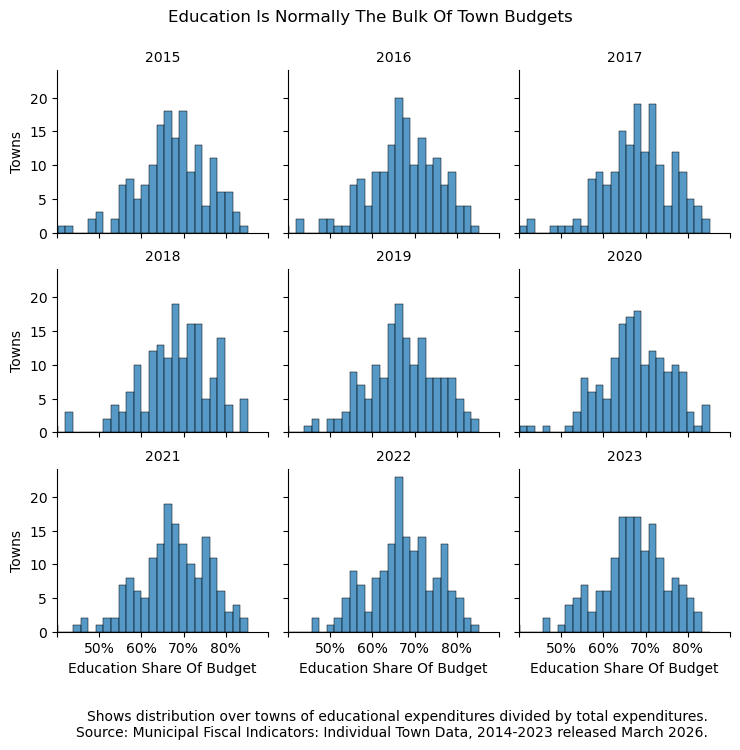

In [9]:
g = sns.displot(data=town_total_income[town_total_income['Fiscal Year End'] >= 2015],
                x='Education Share Of Budget',
                col='Fiscal Year End', col_wrap=3, height=2.5 )

g.fig.suptitle("Education Is Normally The Bulk Of Town Budgets")

g.set_titles(col_template="{col_name}")

for ax in g.axes.flat:
    ax.set_ylabel('Towns')
    ax.set_xlim(0.4,.9)
    ax.xaxis.set_major_formatter(perci_formatter)
    labels = ax.xaxis.get_ticklabels()
    if len(labels) > 0:
        labels[0].set_visible(False)
        labels[-1].set_visible(False)

plt.subplots_adjust(top=.9, bottom=0.15)

line1 = "Shows distribution over towns of educational expenditures divided by total expenditures.\n"
line2 = "Source: Municipal Fiscal Indicators: Individual Town Data, 2014-2023 released March 2026."
g.fig.text(.95,.01, line1+line2, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/education_share_of_budget.png", dpi=200, metadata=png_metadata)

plt.show()

### Select peer group
From district-level data

In [11]:
# get data
district_band_income = district_total_income[district_total_income['Size of adjusted gross income'] != 'Total'].copy()
district_total_income = district_total_income[district_total_income['Size of adjusted gross income'] == 'Total'].copy()

# limit to peers
district_total_income = district_total_income[(district_total_income[PEERVAR] > 0)]
district_total_income = district_total_income[district_total_income['Fiscal Year End'] > 2014]
#district_total_income = district_total_income[district_total_income['Fiscal Year End']

# for plotting
district_total_income['Granby'] = (district_total_income[PEERVAR] == 2).astype('int')
district_total_income[PEERVAR] = district_total_income[PEERVAR]\
                                .where(~district_total_income['District'].str.startswith('Region'), 3)

district_total_income.sort_values(by=['Year', PEERVAR, 'Granby'], inplace=True)

#### Color scheme

In [12]:
# color scheme
school_cols = {x:(0.69, 0.77, 0.87, .4) for x in district_total_income['District'].unique()}
school_cols = school_cols | {'Granby School District': 'black', 'Average': 'darkblue'}

peer_cols = {3: (0.19, 0.27, 0.57, .4),
             2: 'black',
             1: (0.529, 0.808, 0.922, .4)}

flag_cols = {0:(0.69, 0.77, 0.87, .4), 1:'black'}

In [13]:
# show districts in peer group
print(f"Using peer variable: {PEERVAR}\n")
for d in sorted(district_total_income[district_total_income[PEERVAR] > 0].District.unique()):
    print(d)

Using peer variable: finproj

Bolton School District
Colchester School District
East Granby School District
East Lyme School District
Ellington School District
Granby School District
Litchfield School District
New Fairfield School District
Newtown School District
North Haven School District
Regional School District 06
Regional School District 10
Regional School District 13
Regional School District 14
Regional School District 17
Regional School District 18
Salem School District
Sherman School District
Somers School District
Southington School District
Stonington School District
Suffield School District
Tolland School District
Woodstock School District


In [14]:
_df = district_total_income[district_total_income['Fiscal Year End'] == 2022]\
    [['District', 'Total income Amount', 'Real Income Per Taxpayer', 'Equalized Net Grand List MM',
      '% Age 65+', '% HH w/Children', 'Enrollment Rate', '% Owner Occ', '% SNAP', '% w/Bachelors+', '% Management']]\
    .rename(columns={'Equalized Net Grand List MM': 'EQ Grand List'}).copy().sort_values('Real Income Per Taxpayer')

_df['District Income'] = _df["Total income Amount"]/1000
_df['EQ Grand List'] = _df['EQ Grand List']/1000
_df[['District', 'District Income', 'EQ Grand List', 'Real Income Per Taxpayer', '% Age 65+', 'Enrollment Rate', '% Owner Occ', '% SNAP', '% w/Bachelors+', '% Management']]\
    .style.format({"District Income": "${:,.0f} B", "EQ Grand List": "${:,.2f} B", "Real Income Per Taxpayer": "${:,.0f}"} |
                  {'Enrollment Rate': "{:.1%}"} |
                  {x: "{:.0f}%" for x in ['% Age 65+', '% Owner Occ', '% SNAP', '% w/Bachelors+', '% Management']})\
    .hide(axis="index")

District,District Income,EQ Grand List,Real Income Per Taxpayer,% Age 65+,Enrollment Rate,% Owner Occ,% SNAP,% w/Bachelors+,% Management
Colchester School District,$798 B,$2.25 B,"$59,544",30%,14.4%,80%,5%,46%,58%
Southington School District,"$2,242 B",$6.34 B,"$63,326",37%,14.1%,84%,4%,42%,51%
Salem School District,$227 B,$0.66 B,"$64,327",32%,13.2%,88%,3%,54%,52%
Woodstock School District,$438 B,$1.42 B,"$65,129",31%,15.0%,85%,1%,45%,47%
East Granby School District,$294 B,$1.01 B,"$68,519",39%,16.2%,81%,10%,48%,38%
North Haven School District,"$1,450 B",$5.00 B,"$69,656",40%,13.3%,82%,4%,47%,52%
Ellington School District,$942 B,$2.15 B,"$70,020",33%,15.4%,70%,3%,50%,62%
Bolton School District,$306 B,$0.75 B,"$73,503",33%,14.7%,90%,4%,48%,58%
Regional School District 10,$947 B,$2.61 B,"$73,506",31%,14.4%,92%,3%,46%,51%
Regional School District 17,$905 B,$2.64 B,"$73,786",35%,12.1%,92%,3%,51%,56%


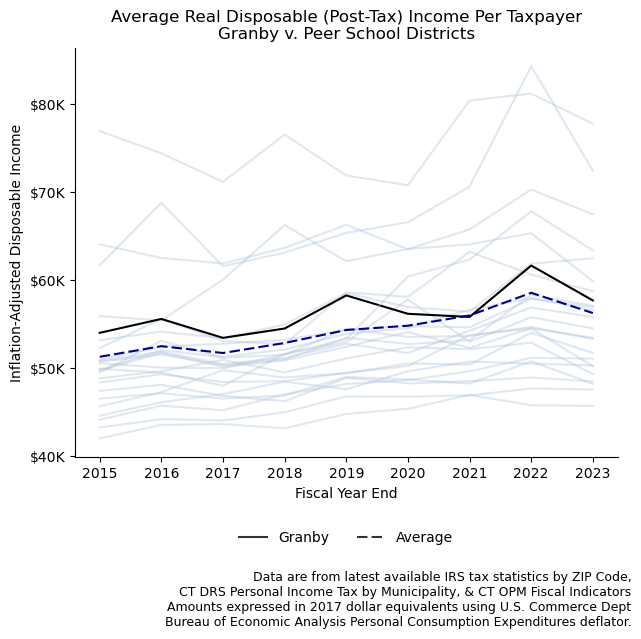

In [15]:
_ave = pd.DataFrame(district_total_income.groupby('Fiscal Year End')['Real Disposable Income Per Taxpayer'].mean()).reset_index(drop=False)
_ave['District'] = 'Average'

tmpdf = pd.concat([district_total_income, _ave], axis=0, ignore_index=True)
tmpdf['Granby'] = 'Other'
tmpdf['Granby'] = tmpdf['Granby'].where(~tmpdf['District'].str.startswith('Granby'), 'Granby')
tmpdf['Granby'] = tmpdf['Granby'].where(~tmpdf['District'].str.startswith('Average'), 'Average')

fig, g = plt.subplots(1, 1, figsize=(7,6.5))
sns.lineplot(data=tmpdf,
                y='Real Disposable Income Per Taxpayer', 
                x='Fiscal Year End', hue='District',
                style='Granby', dashes=[(None, None), (None, None), (5, 2)],
                 ax=g,
                palette=school_cols)
sns.despine()
g.set_title('Average Real Disposable (Post-Tax) Income Per Taxpayer\nGranby v. Peer School Districts')
g.set_ylabel('Inflation-Adjusted Disposable Income')
g.yaxis.set_major_formatter(dollar_k_formatter)
g.legend()

h, lab = g.get_legend_handles_labels()
g.legend(h[-2:], lab[-2:])
sns.move_legend(g, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncols=2, frameon=False)


plt.subplots_adjust(top=.9, bottom=0.27)

line3 = "Amounts expressed in 2017 dollar equivalents using U.S. Commerce Dept\n"
line4 = "Bureau of Economic Analysis Personal Consumption Expenditures deflator."
line1 = "Data are from latest available IRS tax statistics by ZIP Code,\n"
line2 = "CT DRS Personal Income Tax by Municipality, & CT OPM Fiscal Indicators\n"
fig.text(.92, .01, line1 + line2 + line3 + line4, ha='right', fontsize=9)

plt.savefig(f"./charts/budget/{PEERVAR}/peer_real_disposable_income.png", dpi=200, metadata=png_metadata)

plt.show()

### Relative to tax base

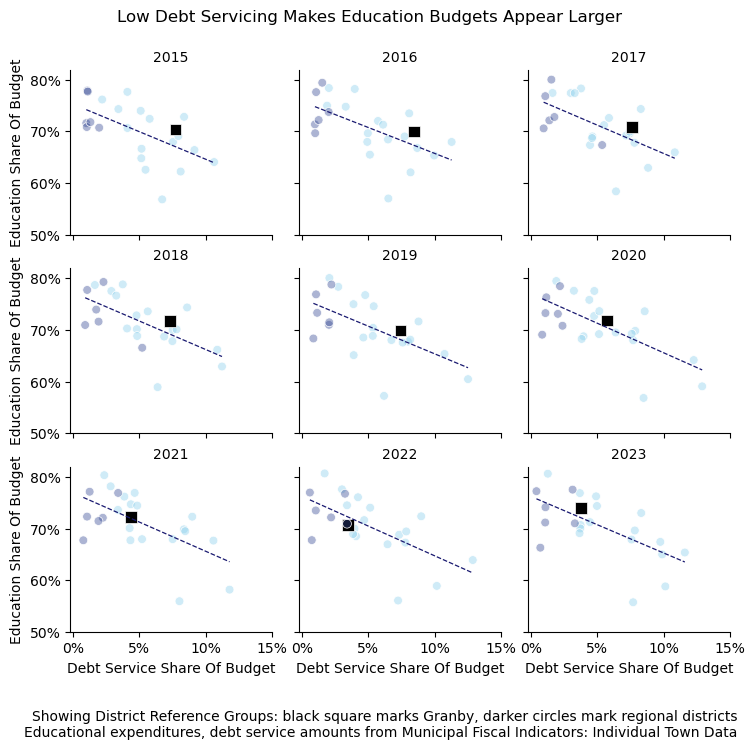

In [16]:
g = sns.relplot(data=district_total_income[(district_total_income['Debt Service Share Of Budget'] <= .15)
                                        & (district_total_income['Education Share Of Budget'] >= .5)],
                col='Fiscal Year End', col_wrap=3,
                x='Debt Service Share Of Budget', y='Education Share Of Budget',
                height=2.5, palette=peer_cols, legend=None,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],
                hue = PEERVAR,)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Debt Service Share Of Budget', y='Education Share Of Budget', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.set_ylim(bottom=.5)
    ax.set_xlim(right=.15)
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.xaxis.set_major_formatter(perci_formatter)
    #plt.xscale('log') 

g.fig.suptitle("Low Debt Servicing Makes Education Budgets Appear Larger")

plt.subplots_adjust(top=.9, bottom=0.15)
line1 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts\n"
line2 = "Educational expenditures, debt service amounts from Municipal Fiscal Indicators: Individual Town Data"
g.fig.text(.99, .01, line1 + line2, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/education_relative_to_debt.png", dpi=200, metadata=png_metadata)

plt.show()

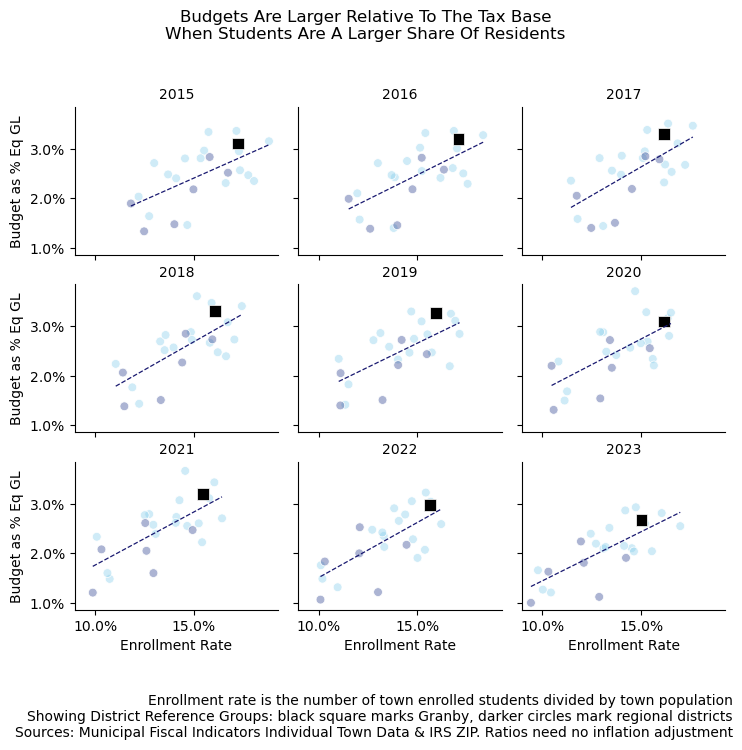

In [17]:
g = sns.relplot(data=district_total_income.rename(columns={'Budget Share Of Eq Grand List': 'Budget as % Eq GL'}),
                col='Fiscal Year End', col_wrap=3,
                x='Enrollment Rate', y='Budget as % Eq GL', 
                height=2.5,  legend=None,
                hue = PEERVAR, palette=peer_cols,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],)

g.set_titles(col_template="{col_name}")

g.map_dataframe(sns.regplot, x='Enrollment Rate', y='Budget as % Eq GL', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(perc_formatter)
    ax.yaxis.set_major_formatter(perc_formatter)

g.fig.suptitle("Budgets Are Larger Relative To The Tax Base\nWhen Students Are A Larger Share Of Residents")

plt.subplots_adjust(top=.85, bottom=0.18)
line1 = "Enrollment rate is the number of town enrolled students divided by town population\n"
line2 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts\n"
line3 = "Sources: Municipal Fiscal Indicators Individual Town Data & IRS ZIP. Ratios need no inflation adjustment"
g.fig.text(.99, .01, line1 + line2 + line3, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/budget_gl_share_v_studentperc.png", dpi=200, metadata=png_metadata)

plt.show()

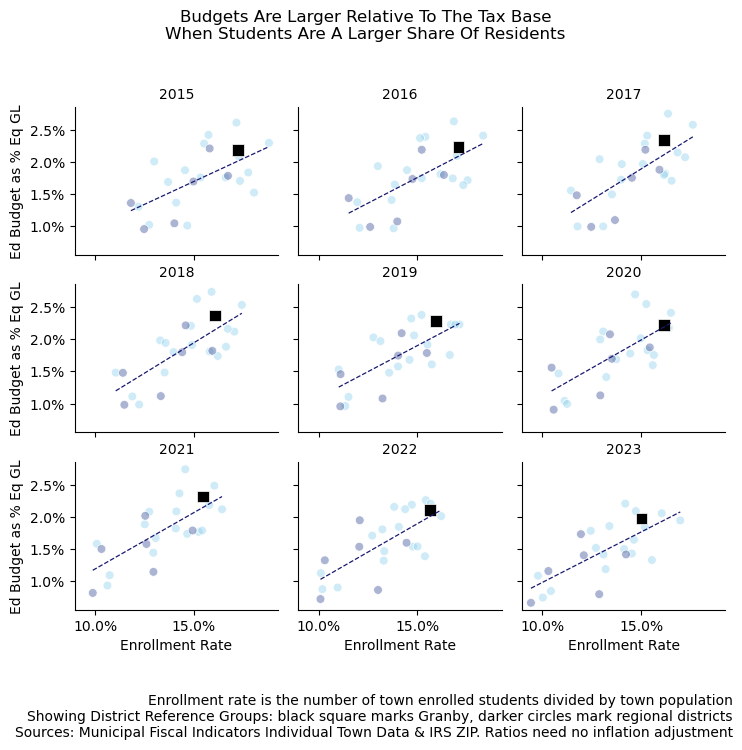

In [18]:
g = sns.relplot(data=district_total_income.rename(columns={'Education Share Of Eq Grand List': 'Ed Budget as % Eq GL'}),
                col='Fiscal Year End', col_wrap=3,
                x='Enrollment Rate', y='Ed Budget as % Eq GL', 
                height=2.5,  legend=None,
                hue = PEERVAR, palette=peer_cols,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],)

g.set_titles(col_template="{col_name}")

g.map_dataframe(sns.regplot, x='Enrollment Rate', y='Ed Budget as % Eq GL', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(perc_formatter)
    ax.yaxis.set_major_formatter(perc_formatter)

g.fig.suptitle("Budgets Are Larger Relative To The Tax Base\nWhen Students Are A Larger Share Of Residents")

plt.subplots_adjust(top=.85, bottom=0.18)
line1 = "Enrollment rate is the number of town enrolled students divided by town population\n"
line2 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts\n"
line3 = "Sources: Municipal Fiscal Indicators Individual Town Data & IRS ZIP. Ratios need no inflation adjustment"
g.fig.text(.99, .01, line1 + line2 + line3, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/edbudget_gl_share_v_studentperc.png", dpi=200, metadata=png_metadata)

plt.show()

### Relative to Grand List
#### Less Important

Taxes are paid out of incomes, not home values. The equalized grand list is useful as a measure of wealth but is messy because tax bases differ by locality.

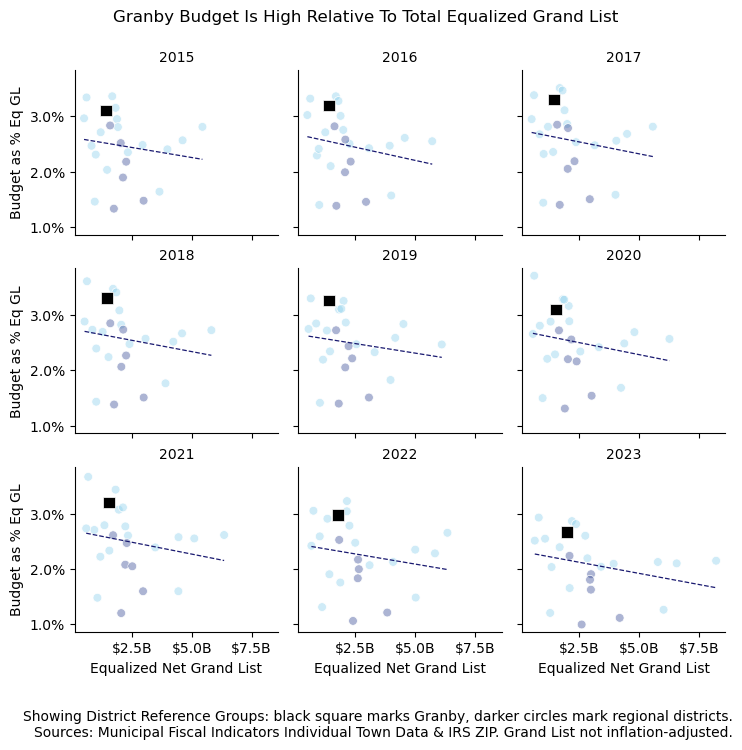

In [19]:
g = sns.relplot(data=district_total_income[district_total_income['Fiscal Year End'] > 2014]\
                     .rename(columns={'Budget Share Of Eq Grand List': 'Budget as % Eq GL'}),
                col='Fiscal Year End', col_wrap=3,
                x='Equalized Net Grand List', y='Budget as % Eq GL', 
                height=2.5,  legend=None,
                hue = PEERVAR, palette=peer_cols,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],)

g.set_titles(col_template="{col_name}")

g.map_dataframe(sns.regplot, x='Equalized Net Grand List', y='Budget as % Eq GL', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(dollar_realbb_formatter)
    ax.yaxis.set_major_formatter(perc_formatter)

g.fig.suptitle("Granby Budget Is High Relative To Total Equalized Grand List")

plt.subplots_adjust(top=.9, bottom=0.15)
line1 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts.\n"
line2 = "Sources: Municipal Fiscal Indicators Individual Town Data & IRS ZIP. Grand List not inflation-adjusted."
g.fig.text(.99, .01, line1 + line2, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/budget_gl_share_v_gl.png", dpi=200, metadata=png_metadata)

plt.show()

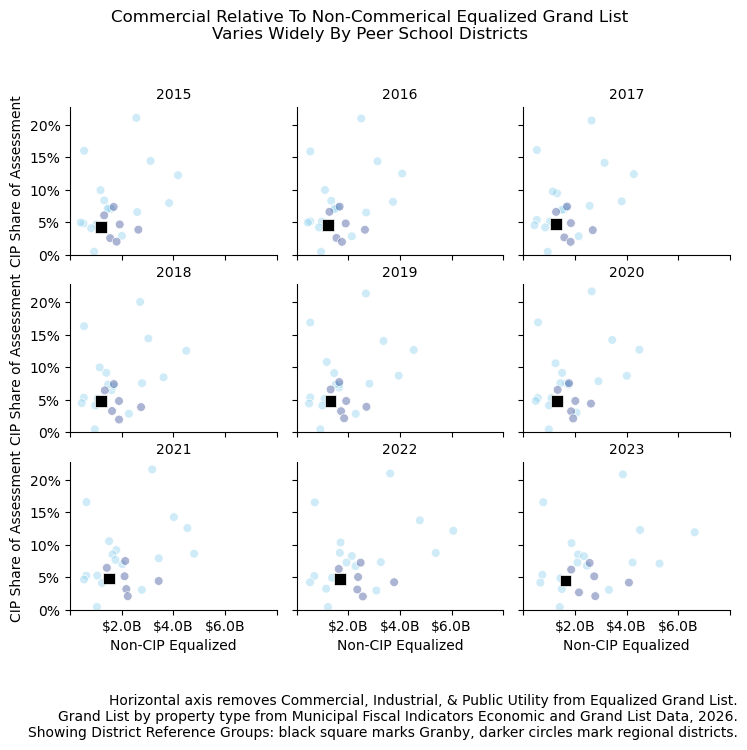

In [20]:
g = sns.relplot(data=district_total_income,
                col='Fiscal Year End', col_wrap=3,
                x='Non-CIP Equalized', y='CIP Share of Assessment',
                height=2.5, legend=None,
                hue = PEERVAR, palette=peer_cols,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],)
g.set_titles(col_template="{col_name}")

for ax in g.axes.flat:
    ax.set_ylim(bottom=0)
    ax.set_xlim(0, 8000000000)
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.xaxis.set_major_formatter(dollar_realbb_formatter)
    labels = ax.xaxis.get_ticklabels()
    if len(labels) > 0:
        labels[0].set_visible(False)
        labels[-1].set_visible(False)

g.fig.suptitle("Commercial Relative To Non-Commerical Equalized Grand List\nVaries Widely By Peer School Districts")

plt.subplots_adjust(top=.85, bottom=0.18)

line3 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts."
line1 = "Horizontal axis removes Commercial, Industrial, & Public Utility from Equalized Grand List.\n"
line2 = "Grand List by property type from Municipal Fiscal Indicators Economic and Grand List Data, 2026.\n"
g.fig.text(.99, .01, line1 + line2 + line3, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/cip_gl_share_v_noncip_gl.png", dpi=200, metadata=png_metadata)

plt.show()

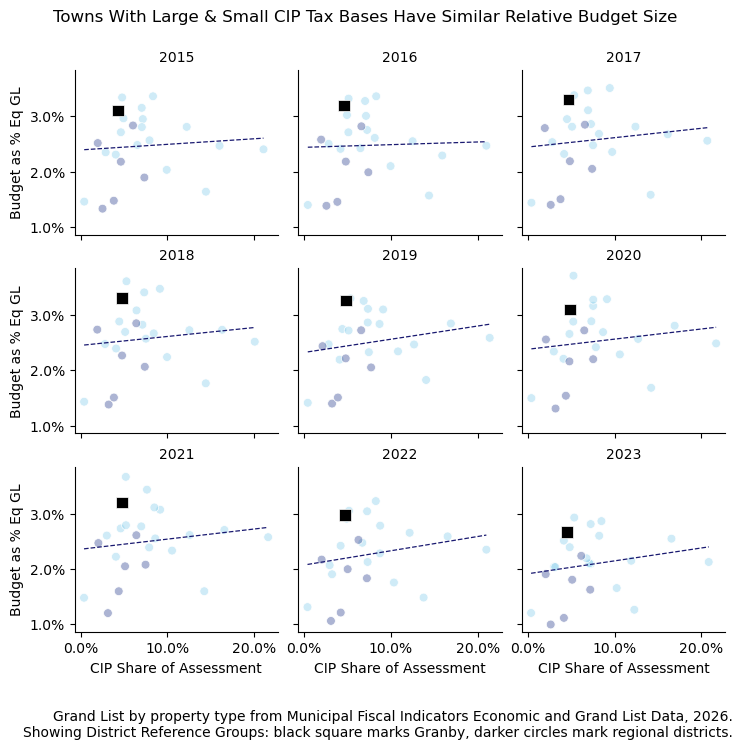

In [21]:

g = sns.relplot(data=district_total_income[district_total_income['Fiscal Year End'] > 2014]\
                     .rename(columns={'Budget Share Of Eq Grand List': 'Budget as % Eq GL'}),
                col='Fiscal Year End', col_wrap=3,
                x='CIP Share of Assessment', y='Budget as % Eq GL', 
                height=2.5,  legend=None,
                hue = PEERVAR, palette=peer_cols,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],)

g.set_titles(col_template="{col_name}")

g.map_dataframe(sns.regplot, x='CIP Share of Assessment', y='Budget as % Eq GL', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(perc_formatter)
    ax.yaxis.set_major_formatter(perc_formatter)


g.fig.suptitle("Towns With Large & Small CIP Tax Bases Have Similar Relative Budget Size")

plt.subplots_adjust(top=.9, bottom=0.15)

line1 = "Grand List by property type from Municipal Fiscal Indicators Economic and Grand List Data, 2026.\n"
line2 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts."
g.fig.text(.99, .01, line1 + line2, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/budget_gl_share_v_cip_share.png", dpi=200, metadata=png_metadata)

plt.show()

In [22]:
district_total_income[district_total_income['Education Share Of Income'] < .025]

,District,Year,Fiscal Year End,Size of adjusted gross income,Number of returns,Number of single returns,Number of joint returns,Number of head of household returns,Number of exemptions,Number of dependents,...,Equalized Net Grand List Per Taxpayer,Real Equalized Net Grand List Per Taxpayer,Flat Tax Per Single Taxpayer,Real Flat Tax Per Taxpayer,Retirement Income Per Return,Retirement Income Index,Average School Enrollment,Population,Enrollment Rate,Granby


## Police & Public Works Spending

In [23]:
# add peer groups
district_accounts = district_accounts.merge(district_total_income, on=['Year', 'District'], how='left').query('Taxpayers.notna()')

In [24]:
district_accounts['Share of Budget'] = np.round(district_accounts['Total'] / district_accounts['Total Expenditures'], 5)
district_accounts['Share of Income'] = np.round(district_accounts['Total'] / district_accounts['Total income Amount'], 5)
district_accounts['Share of Eq GL'] = np.round(district_accounts['Total'] / district_accounts['Equalized Net Grand List'], 5)

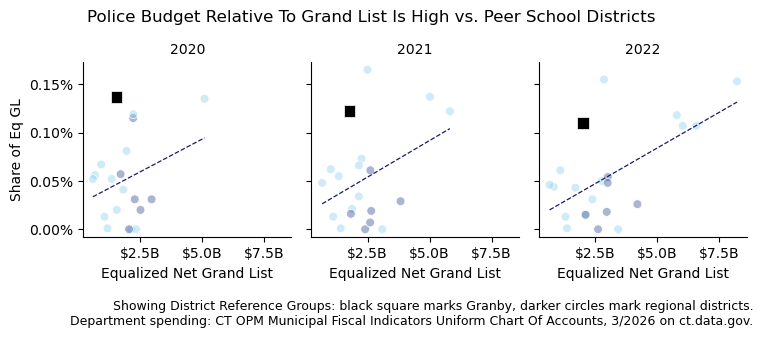

In [25]:
g = sns.relplot(data=district_accounts[district_accounts['Department Description'] == 'Police'],
                col='Year', col_wrap=3,
                y='Share of Eq GL', x='Equalized Net Grand List',
                height=3.25, aspect=.8, legend=None,
                hue = PEERVAR, palette=peer_cols,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, y='Share of Eq GL', x='Equalized Net Grand List', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(dollar_realbb_formatter)
    ax.yaxis.set_major_formatter(perc2_formatter)

g.fig.suptitle("Police Budget Relative To Grand List Is High vs. Peer School Districts")

plt.subplots_adjust(top=.82, bottom=0.28)
line1 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts.\n"
line2 = "Department spending: CT OPM Municipal Fiscal Indicators Uniform Chart Of Accounts, 3/2026 on ct.data.gov."
g.fig.text(.99, .01, line1 + line2, ha='right', fontsize=9)

plt.savefig(f"./charts/budget/{PEERVAR}/district_police_gl_share.png", dpi=200, metadata=png_metadata)

plt.show()

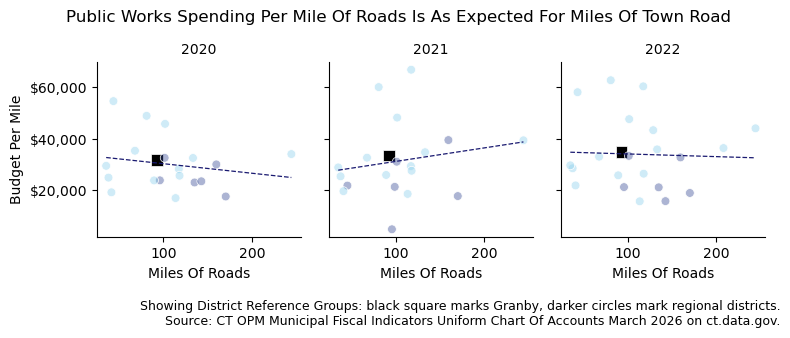

In [26]:
_df = district_accounts[district_accounts['Department Description'] == 'Public Works Total'].copy()
_df['Budget Per Mile'] = _df['Total']/_df['Town Roads']
_df['Miles Of Roads'] = _df['Town Roads']

g = sns.relplot(data=_df,
                col='Year', col_wrap=3,
                y='Budget Per Mile', x='Miles Of Roads',
                height=3.25, aspect=.8, legend=None,
                hue = PEERVAR, palette=peer_cols,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, y='Budget Per Mile', x='Miles Of Roads', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(dollari_formatter)
    labels = ax.xaxis.get_ticklabels()
    if len(labels) > 0:
        labels[0].set_visible(False)
        labels[-1].set_visible(False)

g.fig.suptitle("Public Works Spending Per Mile Of Roads Is As Expected For Miles Of Town Road")

plt.subplots_adjust(top=.82, bottom=0.28)
line1 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts.\n"
line2 = "Source: CT OPM Municipal Fiscal Indicators Uniform Chart Of Accounts March 2026 on ct.data.gov."

g.fig.text(.99, .01, line1 + line2, ha='right', fontsize=9)

plt.savefig(f"./charts/budget/{PEERVAR}/district_works_by_mile.png", dpi=200, metadata=png_metadata)

plt.show()

In [27]:
district_accounts[(district_accounts['Function Description'] == 'Public Works') & (district_accounts['District'].str.startswith('Gran'))]\
                  [['Year', 'Department Description', 'Total']]

,Year,Department Description,Total
3793,2020,Highways/Streets,0.0
3794,2020,Other Public Works,2123543.0
3795,2020,Sewer,0.0
3796,2020,Waste Management,821385.0
3822,2021,Highways/Streets,0.0
3823,2021,Other Public Works,2253658.0
3824,2021,Sewer,0.0
3825,2021,Waste Management,870595.0
3851,2022,Highways/Streets,0.0
3852,2022,Other Public Works,2314008.0


In [28]:
regional_map = {
    'Canaan': 'Regional High School District 01',
    'Cornwall': 'Regional High School District 01',
    'Kent': 'Regional High School District 01',
    'North Canaan': 'Regional High School District 01',
    'Salisbury': 'Regional High School District 01',
    'Sharon': 'Regional High School District 01',
    'Chester': 'Regional High School District 04',
    'Deep River': 'Regional High School District 04',
    'Bethany': 'Regional High School District 04',
    'Orange': 'Regional High School District 05',
    'Woodbridge': 'Regional High School District 05',
    'Essex': 'Regional High School District 05',
    'Goshen': 'Regional School District 06',
    'Morris': 'Regional School District 06',
    'Warren': 'Regional School District 06',
    'Barkhamsted': 'Regional High School District 07',
    'Colebrook': 'Regional High School District 07',
    'New Hartford': 'Regional High School District 07',
    'Norfolk': 'Regional High School District 07',
    'Andover': 'Regional High School District 08',
    'Hebron': 'Regional High School District 08',
    'Marlborough': 'Regional High School District 08',
    'Easton': 'Regional High School District 09',
    'Redding': 'Regional High School District 09',
    'Burlington': 'Regional School District 10',
    'Harwinton': 'Regional School District 10',
    'Chaplin': 'Regional High School District 11',
    'Hampton': 'Regional High School District 11',
    'Scotland': 'Regional High School District 11',
    'Bridgewater': 'Regional School District 12',
    'Roxbury': 'Regional School District 12',
    'Washington': 'Regional School District 12',
    'Durham': 'Regional School District 13',
    'Middlefield': 'Regional School District 13',
    'Bethlehem': 'Regional School District 14',
    'Woodbury': 'Regional School District 14',
    'Middlebury': 'Regional School District 15',
    'Southbury': 'Regional School District 15',
    'Beacon Falls': 'Regional School District 16',
    'Prospect': 'Regional School District 16',
    'Haddam': 'Regional School District 17',
    'Killingworth': 'Regional School District 17',
    'Lyme': 'Regional School District 18',
    'Old Lyme': 'Regional School District 18',
    'Ashford': 'Regional High School District 19',
    'Mansfield': 'Regional High School District 19',
    'Willington': 'Regional High School District 19',
}

In [29]:
# reverse map from schools to towns
dislist = list(district_total_income[district_total_income[PEERVAR] > 0].District.unique())
distowns = [x.replace(' School District', '') for x in dislist if not x.startswith('Regional')]
disreg = [x for x in dislist if x.startswith('Regional')]

regiontowns = []
for k, item in regional_map.items(): 
    regiontowns.append(k) if item in disreg else ''

townlist = distowns + regiontowns
sorted(townlist)

['Bethlehem',
 'Bolton',
 'Burlington',
 'Colchester',
 'Durham',
 'East Granby',
 'East Lyme',
 'Ellington',
 'Goshen',
 'Granby',
 'Haddam',
 'Harwinton',
 'Killingworth',
 'Litchfield',
 'Lyme',
 'Middlefield',
 'Morris',
 'New Fairfield',
 'Newtown',
 'North Haven',
 'Old Lyme',
 'Salem',
 'Sherman',
 'Somers',
 'Southington',
 'Stonington',
 'Suffield',
 'Tolland',
 'Warren',
 'Woodbury',
 'Woodstock']

In [30]:
town_accounts = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/town_chart_of_accounts.parquet')
town_accounts = town_accounts[town_accounts['Town'].isin(townlist)]
town_accounts['Granby'] = (town_accounts['Town'] == 'Granby').astype('int')
town_accounts[PEERVAR] = town_accounts['Town'].isin(regiontowns).astype('int')
town_accounts[PEERVAR] = town_accounts[PEERVAR].where(~town_accounts['Town'].isin(distowns), 3)
town_accounts[PEERVAR] = town_accounts[PEERVAR].where(town_accounts['Granby'] == 0, 2)

In [31]:
town_accounts.columns

Index(['Year', 'Entity Name', 'Function Description', 'Department Description',
       'Salaries Wages', 'Employee Benefits', 'Other', 'Total', 'Town',
       'Total Town Salaries Wages', 'Total Town Employee Benefits',
       'Total Town Other', 'Total Town Total', 'Share of Salaries Wages',
       'Share of Employee Benefits', 'Share of Other', 'Share of Total',
       'Town Area', 'State Roads', 'Town Roads', 'Population',
       'Net Equalized Grand List', 'District', 'Granby', 'finproj'],
      dtype='object')

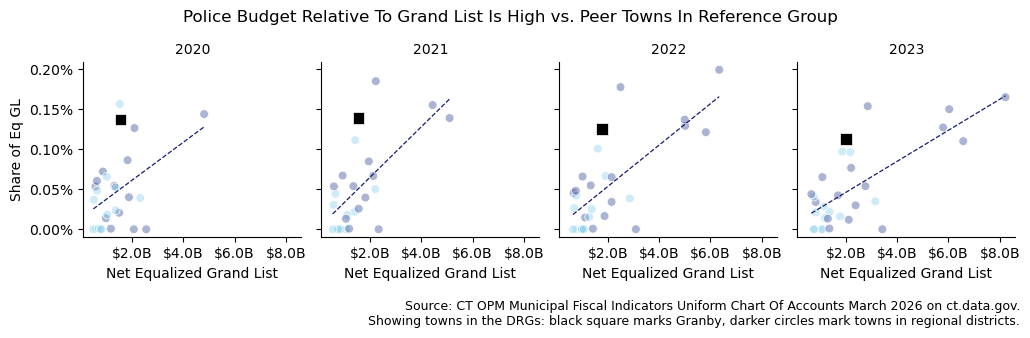

In [32]:
_df = town_accounts[town_accounts['Department Description'] == 'Police'].copy()
_df['Budget Per Person'] = _df['Total']/_df['Population']
_df['Share of Eq GL'] = _df['Total']/_df['Net Equalized Grand List']

g = sns.relplot(data=_df,
                col='Year', col_wrap=4,
                y='Share of Eq GL', x='Net Equalized Grand List',
                height=3.25, aspect=.8, legend=None,
                hue = PEERVAR, palette=peer_cols,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, y='Share of Eq GL', x='Net Equalized Grand List', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(dollar_realbb_formatter)
    ax.yaxis.set_major_formatter(perc2_formatter)

g.fig.suptitle("Police Budget Relative To Grand List Is High vs. Peer Towns In Reference Group")

plt.subplots_adjust(top=.82, bottom=0.28)
line2 = "Showing towns in the DRGs: black square marks Granby, darker circles mark towns in regional districts."
line1 = "Source: CT OPM Municipal Fiscal Indicators Uniform Chart Of Accounts March 2026 on ct.data.gov.\n"
g.fig.text(.99, .01, line1 + line2, ha='right', fontsize=9)

plt.savefig(f"./charts/budget/{PEERVAR}/town_police_gl_share.png", dpi=200, metadata=png_metadata)

plt.show()

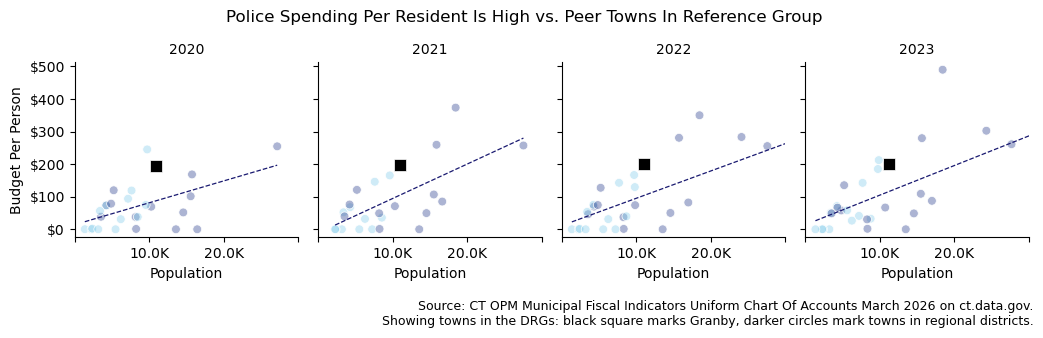

In [33]:
g = sns.relplot(data=_df,
                col='Year', col_wrap=4,
                y='Budget Per Person', x='Population',
                height=3.25, aspect=.8, legend=None,
                hue = PEERVAR, palette=peer_cols,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, y='Budget Per Person', x='Population', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(k_formatter)
    ax.yaxis.set_major_formatter(dollari_formatter)
    ax.set_xlim(0, 30000)
    labels = ax.xaxis.get_ticklabels()
    if len(labels) > 0:
        labels[0].set_visible(False)
        labels[-1].set_visible(False)

g.fig.suptitle("Police Spending Per Resident Is High vs. Peer Towns In Reference Group")

plt.subplots_adjust(top=.82, bottom=0.28)
line2 = "Showing towns in the DRGs: black square marks Granby, darker circles mark towns in regional districts."
line1 = "Source: CT OPM Municipal Fiscal Indicators Uniform Chart Of Accounts March 2026 on ct.data.gov.\n"
g.fig.text(.99, .01, line1 + line2, ha='right', fontsize=9)

plt.savefig(f"./charts/budget/{PEERVAR}/town_police_per_person.png", dpi=200, metadata=png_metadata)

plt.show()

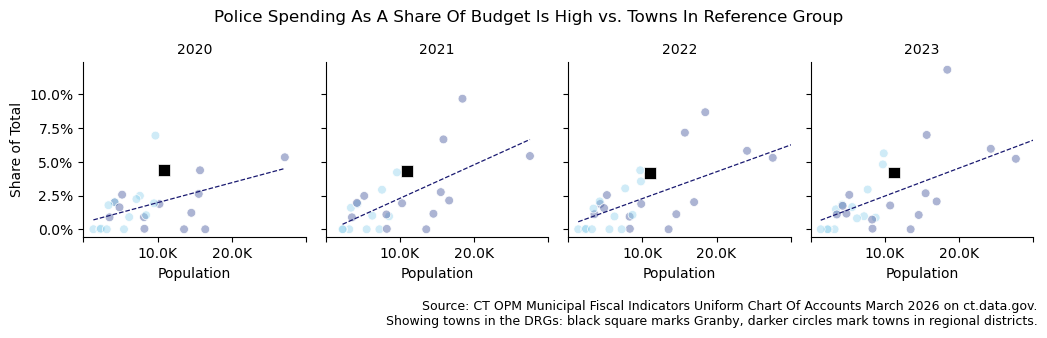

In [34]:
g = sns.relplot(data=town_accounts[town_accounts['Department Description'] == 'Police'],
                col='Year', col_wrap=4,
                y='Share of Total', x='Population',
                height=3.25, aspect=.8, legend=None,
                hue = PEERVAR, palette=peer_cols,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, y='Share of Total', x='Population', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(k_formatter)
    ax.yaxis.set_major_formatter(perc_formatter)
    ax.set_xlim(0, 30000)
    labels = ax.xaxis.get_ticklabels()
    if len(labels) > 0:
        labels[0].set_visible(False)
        labels[-1].set_visible(False)

g.fig.suptitle("Police Spending As A Share Of Budget Is High vs. Towns In Reference Group")

plt.subplots_adjust(top=.82, bottom=0.28)
line2 = "Showing towns in the DRGs: black square marks Granby, darker circles mark towns in regional districts."
line1 = "Source: CT OPM Municipal Fiscal Indicators Uniform Chart Of Accounts March 2026 on ct.data.gov.\n"
g.fig.text(.99, .01, line1 + line2, ha='right', fontsize=9)

plt.savefig(f"./charts/budget/{PEERVAR}/town_police_budget_share.png", dpi=200, metadata=png_metadata)

plt.show()

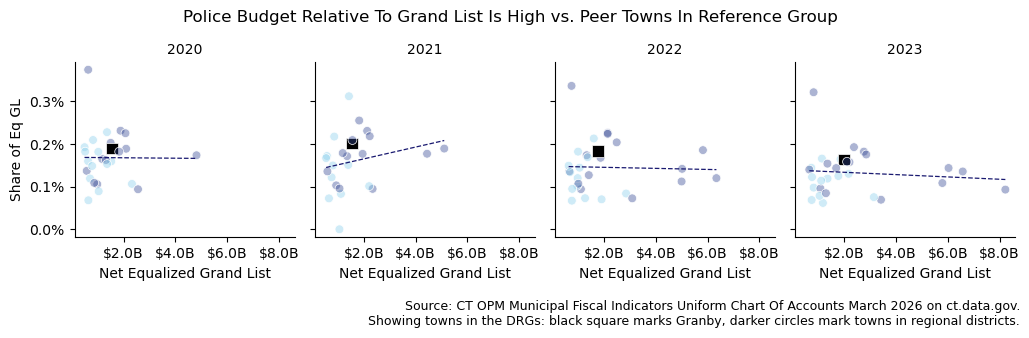

In [35]:
_df = town_accounts[town_accounts['Department Description'] == 'Public Works Total'].copy()
_df['Budget Per Person'] = _df['Total']/_df['Population']
_df['Share of Eq GL'] = _df['Total']/_df['Net Equalized Grand List']

g = sns.relplot(data=_df,
                col='Year', col_wrap=4,
                y='Share of Eq GL', x='Net Equalized Grand List',
                height=3.25, aspect=.8, legend=None,
                hue = PEERVAR, palette=peer_cols,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, y='Share of Eq GL', x='Net Equalized Grand List', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(dollar_realbb_formatter)
    ax.yaxis.set_major_formatter(perc_formatter)

g.fig.suptitle("Police Budget Relative To Grand List Is High vs. Peer Towns In Reference Group")

plt.subplots_adjust(top=.82, bottom=0.28)
line2 = "Showing towns in the DRGs: black square marks Granby, darker circles mark towns in regional districts."
line1 = "Source: CT OPM Municipal Fiscal Indicators Uniform Chart Of Accounts March 2026 on ct.data.gov.\n"
g.fig.text(.99, .01, line1 + line2, ha='right', fontsize=9)

plt.savefig(f"./charts/budget/{PEERVAR}/town_publicworks_gl_share.png", dpi=200, metadata=png_metadata)

plt.show()

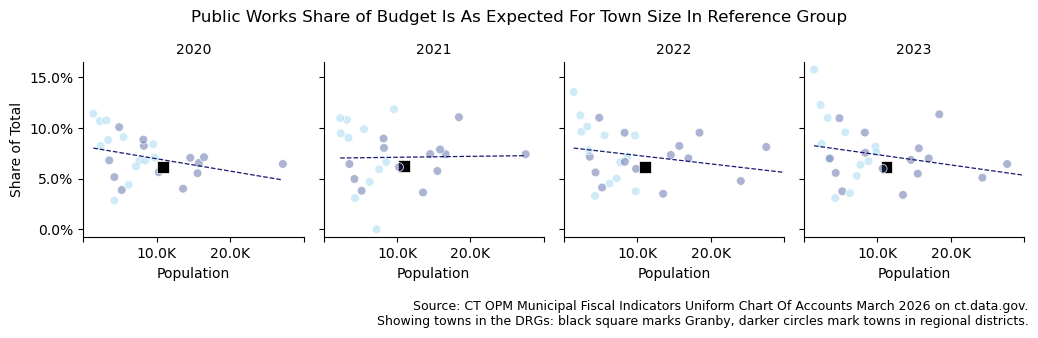

In [36]:
g = sns.relplot(data=_df,
                col='Year', col_wrap=4,
                y='Share of Total', x='Population',
                height=3.25, aspect=.8, legend=None,
                hue = PEERVAR, palette=peer_cols,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, y='Share of Total', x='Population', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(k_formatter)
    ax.yaxis.set_major_formatter(perc_formatter)
    ax.set_xlim(0, 30000)
    labels = ax.xaxis.get_ticklabels()
    if len(labels) > 0:
        labels[0].set_visible(False)
        labels[-1].set_visible(False)


g.fig.suptitle("Public Works Share of Budget Is As Expected For Town Size In Reference Group")

plt.subplots_adjust(top=.82, bottom=0.28)
line2 = "Showing towns in the DRGs: black square marks Granby, darker circles mark towns in regional districts."
line1 = "Source: CT OPM Municipal Fiscal Indicators Uniform Chart Of Accounts March 2026 on ct.data.gov.\n"
g.fig.text(.99, .01, line1 + line2, ha='right', fontsize=9)

plt.savefig(f"./charts/budget/{PEERVAR}/town_publicworks_budget_share.png", dpi=200, metadata=png_metadata)

plt.show()

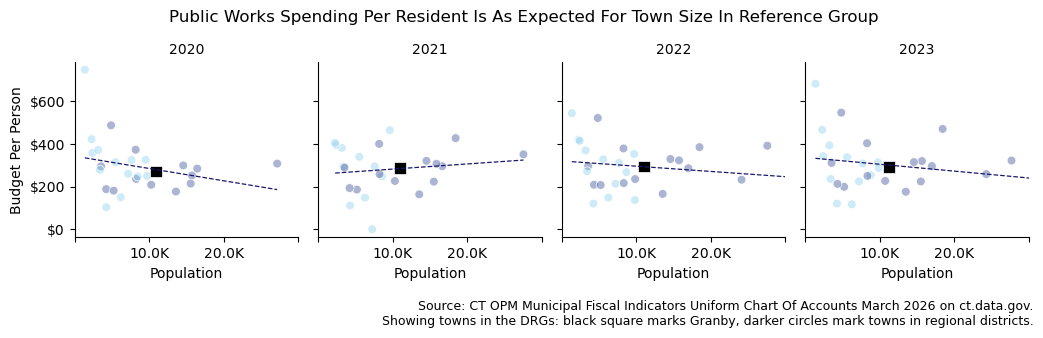

In [37]:
g = sns.relplot(data=_df,
                col='Year', col_wrap=4,
                y='Budget Per Person', x='Population',
                height=3.25, aspect=.8, legend=None,
                hue = PEERVAR, palette=peer_cols,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, y='Budget Per Person', x='Population', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(k_formatter)
    ax.yaxis.set_major_formatter(dollari_formatter)
    ax.set_xlim(0, 30000)
    labels = ax.xaxis.get_ticklabels()
    if len(labels) > 0:
        labels[0].set_visible(False)
        labels[-1].set_visible(False)

g.fig.suptitle("Public Works Spending Per Resident Is As Expected For Town Size In Reference Group")

plt.subplots_adjust(top=.82, bottom=0.28)
line2 = "Showing towns in the DRGs: black square marks Granby, darker circles mark towns in regional districts."
line1 = "Source: CT OPM Municipal Fiscal Indicators Uniform Chart Of Accounts March 2026 on ct.data.gov.\n"

g.fig.text(.99, .01, line1 + line2, ha='right', fontsize=9)

plt.savefig(f"./charts/budget/{PEERVAR}/town_publicworks_per_person.png", dpi=200, metadata=png_metadata)

plt.show()

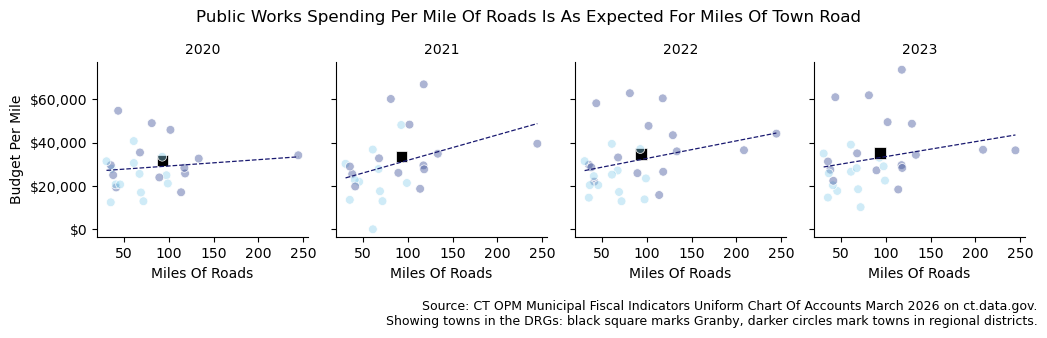

In [38]:
_df = town_accounts[town_accounts['Department Description'] == 'Public Works Total'].copy()
_df['Budget Per Mile'] = _df['Total']/_df['Town Roads']
_df['Miles Of Roads'] = _df['Town Roads']

g = sns.relplot(data=_df,
                col='Year', col_wrap=4,
                y='Budget Per Mile', x='Miles Of Roads',
                height=3.25, aspect=.8, legend=None,
                hue = PEERVAR, palette=peer_cols,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, y='Budget Per Mile', x='Miles Of Roads', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(dollari_formatter)
    labels = ax.xaxis.get_ticklabels()
    if len(labels) > 0:
        labels[0].set_visible(False)
        labels[-1].set_visible(False)

g.fig.suptitle("Public Works Spending Per Mile Of Roads Is As Expected For Miles Of Town Road")

plt.subplots_adjust(top=.82, bottom=0.28)
line2 = "Showing towns in the DRGs: black square marks Granby, darker circles mark towns in regional districts."
line1 = "Source: CT OPM Municipal Fiscal Indicators Uniform Chart Of Accounts March 2026 on ct.data.gov.\n"

g.fig.text(.99, .01, line1 + line2, ha='right', fontsize=9)

plt.savefig(f"./charts/budget/{PEERVAR}/town_publicworks_per_mile.png", dpi=200, metadata=png_metadata)
plt.show()